# Amazon Product Review Sentiment Analysis

## Horizon TechX Internship Project
### AI & Data Science Domain

**Intern Name:** Karthik Neduri  
**Task:** Sentiment Analysis  
**Tools Used:** Python, Pandas, NLTK, Scikit-learn, Matplotlib, Seaborn  
**Environment:** Google Colab

# 1. Importing Required Libraries

In [76]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Initialize directory structure
os.makedirs('Charts', exist_ok=True)

In [48]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 2. Dataset Loading

In [49]:
# Read the dataset

reviews = []

with open('test.ft.txt', 'r', encoding='utf-8') as file:
    for i, line in enumerate(file):

        # Limit rows for faster processing
        if i >= 50000:
            break

        reviews.append(line)

# Check total loaded reviews
print("Total Reviews Loaded:", len(reviews))

Total Reviews Loaded: 50000


# 3. Data Preprocessing & DataFrame Creation

In [50]:
# Create lists for labels and reviews

sentiments = []
texts = []

for review in reviews:

    # Positive Review
    if review.startswith('__label__2'):
        sentiments.append('Positive')
        texts.append(review.replace('__label__2', '').strip())

    # Negative Review
    elif review.startswith('__label__1'):
        sentiments.append('Negative')
        texts.append(review.replace('__label__1', '').strip())

# Create DataFrame
df = pd.DataFrame({
    'Sentiment': sentiments,
    'Review': texts
})

# Display first 5 rows
df.head()

,Sentiment,Review
0,Positive,Great CD: My lovely Pat has one of the GREAT v...
1,Positive,One of the best game music soundtracks - for a...
2,Negative,Batteries died within a year ...: I bought thi...
3,Positive,"works fine, but Maha Energy is better: Check o..."
4,Positive,Great for the non-audiophile: Reviewed quite a...


# 4. Exploratory Data Analysis (EDA)

In [51]:
# Dataset Information

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (50000, 2)

Column Names:
Index(['Sentiment', 'Review'], dtype='object')

Sentiment Distribution:
Sentiment
Positive    25374
Negative    24626
Name: count, dtype: int64

Missing Values:
Sentiment    0
Review       0
dtype: int64


# 5. Sentiment Distribution Analysis

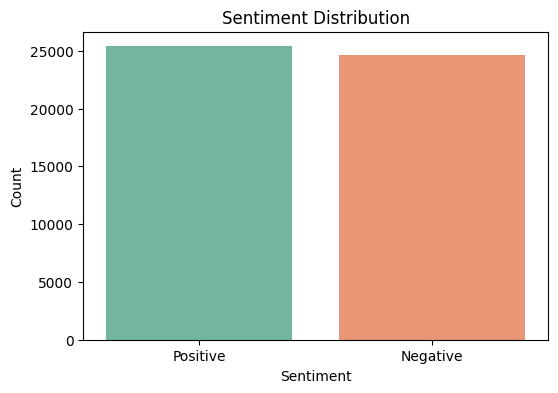

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sentiment',
    data=df,
    palette='Set2'
)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()

# 6. Review Length Analysis

In [53]:
# Create Review Length Column

df['Review_Length'] = df['Review'].apply(len)

# Display first 5 rows
df.head()

,Sentiment,Review,Review_Length
0,Positive,Great CD: My lovely Pat has one of the GREAT v...,533
1,Positive,One of the best game music soundtracks - for a...,816
2,Negative,Batteries died within a year ...: I bought thi...,335
3,Positive,"works fine, but Maha Energy is better: Check o...",229
4,Positive,Great for the non-audiophile: Reviewed quite a...,412


# 7. Review Length Distribution

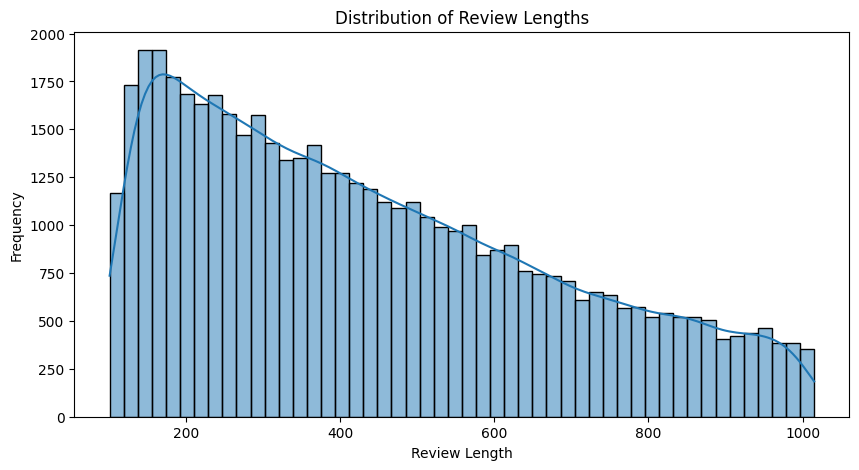

In [54]:
# Review Length Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df['Review_Length'],
    bins=50,
    kde=True
)

plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

# Save Chart
plt.savefig(
    'Charts/review_length_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 8. Text Preprocessing

## 8.1 Text Cleaning Function

In [55]:
# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Stopwords
stop_words = set(stopwords.words('english'))

# Text Cleaning Function

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and apply lemmatization
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into sentence
    return ' '.join(cleaned_words)

## 8.2 Applying Text Cleaning

In [56]:
# Apply Cleaning Function

df['Cleaned_Review'] = df['Review'].apply(clean_text)

# Display Sample Cleaned Reviews
df[['Review', 'Cleaned_Review']].head()

,Review,Cleaned_Review
0,Great CD: My lovely Pat has one of the GREAT v...,great cd lovely pat one great voice generation...
1,One of the best game music soundtracks - for a...,one best game music soundtrack game didnt real...
2,Batteries died within a year ...: I bought thi...,battery died within year bought charger jul wo...
3,"works fine, but Maha Energy is better: Check o...",work fine maha energy better check maha energy...
4,Great for the non-audiophile: Reviewed quite a...,great nonaudiophile reviewed quite bit combo p...


# 9. Sentiment Encoding

In [57]:
# Convert Sentiment Labels into Numbers

df['Sentiment_Label'] = df['Sentiment'].map({
    'Positive': 1,
    'Negative': 0
})

# Display Sample Data
df.head()

,Sentiment,Review,Review_Length,Cleaned_Review,Sentiment_Label
0,Positive,Great CD: My lovely Pat has one of the GREAT v...,533,great cd lovely pat one great voice generation...,1
1,Positive,One of the best game music soundtracks - for a...,816,one best game music soundtrack game didnt real...,1
2,Negative,Batteries died within a year ...: I bought thi...,335,battery died within year bought charger jul wo...,0
3,Positive,"works fine, but Maha Energy is better: Check o...",229,work fine maha energy better check maha energy...,1
4,Positive,Great for the non-audiophile: Reviewed quite a...,412,great nonaudiophile reviewed quite bit combo p...,1


# 10. TF-IDF Feature Engineering

## 10.1 Converting Text into Numerical Features

In [58]:
# Define Features and Target

X = df['Cleaned_Review']
y = df['Sentiment_Label']

# TF-IDF Vectorization

vectorizer = TfidfVectorizer(max_features=5000)

X_vectorized = vectorizer.fit_transform(X)

# Check Shape
print("Feature Matrix Shape:", X_vectorized.shape)

Feature Matrix Shape: (50000, 5000)


# 11. Train-Test Split

In [77]:
# Split Dataset with stratification for better class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (40000, 5000)
X_test Shape: (10000, 5000)


# 12. Logistic Regression Model Training

## 12.1 Training the Sentiment Classification Model

In [60]:
# Initialize Logistic Regression Model

model = LogisticRegression()

# Train the Model

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


# 13. Model Evaluation

## 13.1 Prediction and Accuracy Evaluation

In [61]:
# Make Predictions

y_pred = model.predict(X_test)

# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 86.89 %


## 13.2 Classification Report

In [62]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4928
           1       0.87      0.87      0.87      5072

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



## 13.3 Confusion Matrix

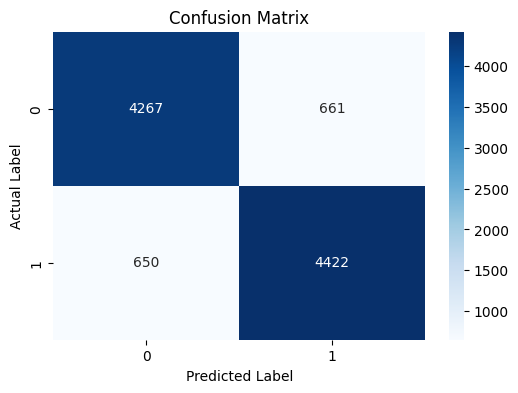

In [63]:
# Create Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Save Chart
plt.savefig(
    'Charts/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 14. WordCloud Visualization

## 14.1 Custom Stopwords for Better WordClouds

In [64]:
custom_stopwords = set([
    'book',
    'movie',
    'film',
    'read',
    'one',
    'dvd',
    'cd',
    'album',
    'story',
    'character'
])

## 14.2 Improved Positive WordCloud

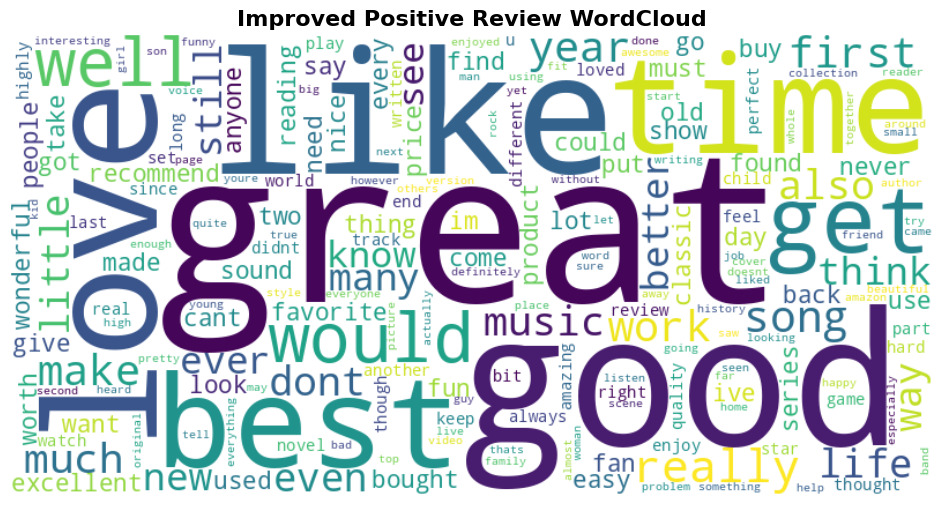

In [78]:
# Optimized WordCloud using frequency dictionary
pos_freq = Counter(' '.join(df[df['Sentiment'] == 'Positive']['Cleaned_Review']).split())
for word in custom_stopwords: pos_freq.pop(word, None)

positive_wordcloud = WordCloud(
    width=800, height=400, background_color='white'
).generate_from_frequencies(pos_freq)

plt.figure(figsize=(12,6))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Improved Positive Review WordCloud', fontsize=16, fontweight='bold')
plt.savefig('Charts/positive_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

#14.3 Improved Negative WordCloud

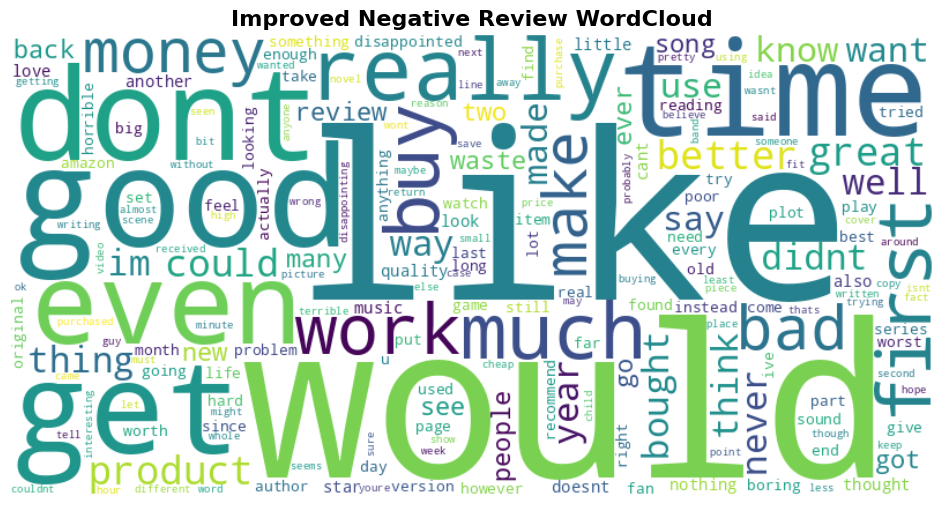

In [79]:
# Optimized WordCloud using frequency dictionary
neg_freq = Counter(' '.join(df[df['Sentiment'] == 'Negative']['Cleaned_Review']).split())
for word in custom_stopwords: neg_freq.pop(word, None)

negative_wordcloud = WordCloud(
    width=800, height=400, background_color='white'
).generate_from_frequencies(neg_freq)

plt.figure(figsize=(12,6))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Improved Negative Review WordCloud', fontsize=16, fontweight='bold')
plt.savefig('Charts/negative_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

# 15. Custom Sentiment Prediction System

## 15.1 Predicting Sentiment for New Reviews

In [67]:
# Custom Prediction Function

def predict_sentiment(review):

    # Clean the review
    cleaned_review = clean_text(review)

    # Convert to vector
    review_vector = vectorizer.transform([cleaned_review])

    # Predict sentiment
    prediction = model.predict(review_vector)[0]

    # Display result
    if prediction == 1:
        return "Positive Review 😊"
    else:
        return "Negative Review 😞"

## 15.2 Testing the Prediction System

In [68]:
# Test Positive Review

review1 = "This product is absolutely amazing and works perfectly."

print("Review:", review1)
print("Prediction:", predict_sentiment(review1))

print("\n")

# Test Negative Review

review2 = "Worst product ever. Completely disappointed with the quality."

print("Review:", review2)
print("Prediction:", predict_sentiment(review2))

Review: This product is absolutely amazing and works perfectly.
Prediction: Positive Review 😊


Review: Worst product ever. Completely disappointed with the quality.
Prediction: Negative Review 😞


# 16. Additional Visualizations


## 16.1 Sentiment Percentage Pie Chart

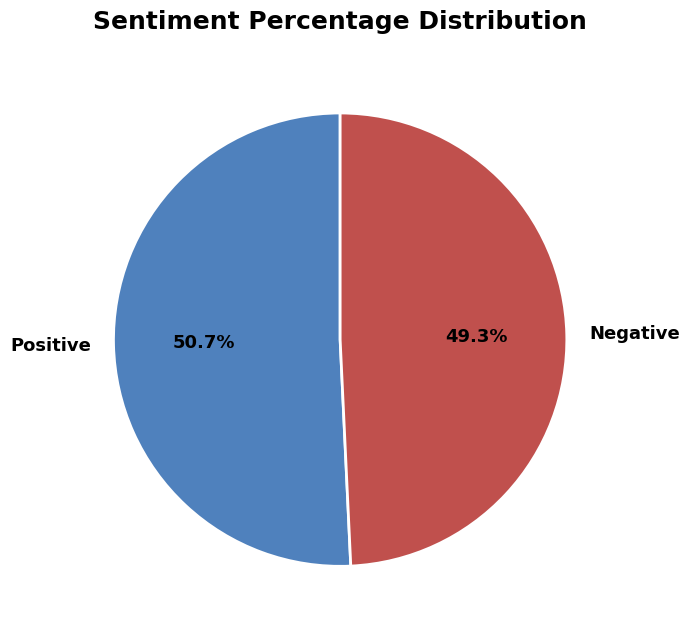

In [70]:
# Modern Sentiment Percentage Pie Chart

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7,7))

colors = ['#4F81BD', '#C0504D']

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={
        'fontsize': 13,
        'fontweight': 'bold'
    }
)

plt.title(
    'Sentiment Percentage Distribution',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

# Save Chart
plt.savefig(
    'Charts/sentiment_percentage_pie_chart.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 16.2 Top 10 Positive Words

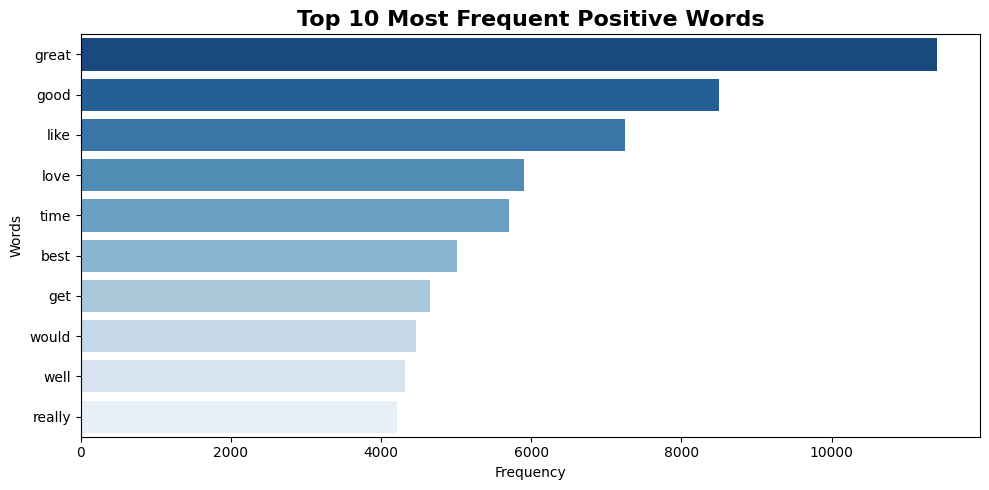

In [71]:
from collections import Counter

# Combine Positive Reviews
positive_text = ' '.join(
    df[df['Sentiment'] == 'Positive']['Cleaned_Review']
)

# Split into Words
positive_words = positive_text.split()

# Remove Custom Stopwords
positive_words = [
    word for word in positive_words
    if word not in custom_stopwords
]

# Count Most Common Words
positive_word_freq = Counter(positive_words).most_common(10)

# Convert to DataFrame
positive_freq_df = pd.DataFrame(
    positive_word_freq,
    columns=['Word', 'Frequency']
)

# Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=positive_freq_df,
    palette='Blues_r'
)

plt.title(
    'Top 10 Most Frequent Positive Words',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Frequency')
plt.ylabel('Words')

plt.tight_layout()

# Save Chart
plt.savefig(
    'Charts/top_positive_words.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 16.3 Top 10 Negative Words

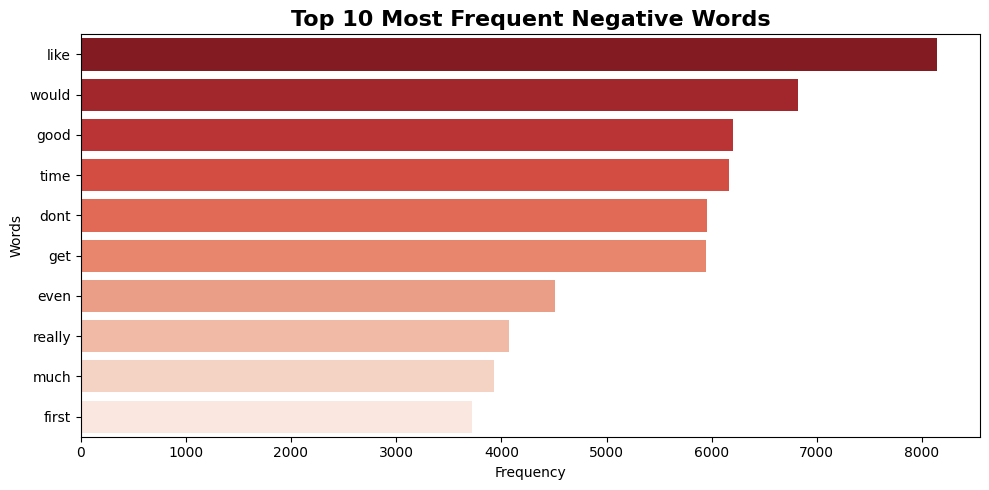

In [72]:
# Combine Negative Reviews
negative_text = ' '.join(
    df[df['Sentiment'] == 'Negative']['Cleaned_Review']
)

# Split into Words
negative_words = negative_text.split()

# Remove Custom Stopwords
negative_words = [
    word for word in negative_words
    if word not in custom_stopwords
]

# Count Most Common Words
negative_word_freq = Counter(negative_words).most_common(10)

# Convert to DataFrame
negative_freq_df = pd.DataFrame(
    negative_word_freq,
    columns=['Word', 'Frequency']
)

# Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=negative_freq_df,
    palette='Reds_r'
)

plt.title(
    'Top 10 Most Frequent Negative Words',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Frequency')
plt.ylabel('Words')

plt.tight_layout()

# Save Chart
plt.savefig(
    'Charts/top_negative_words.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 16.4 Review Length Comparison by Sentiment

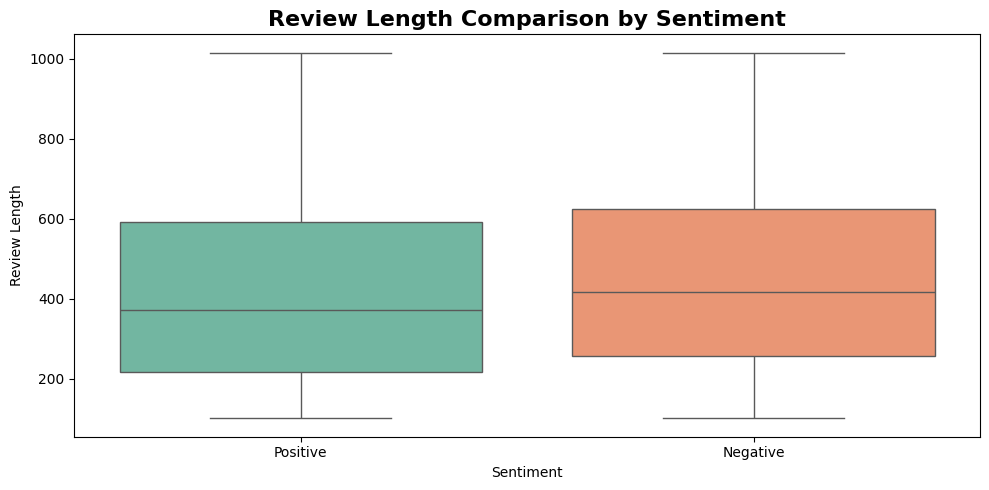

In [73]:
# Review Length Comparison by Sentiment

plt.figure(figsize=(10,5))

sns.boxplot(
    x='Sentiment',
    y='Review_Length',
    data=df,
    palette='Set2'
)

plt.title(
    'Review Length Comparison by Sentiment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Review Length')

plt.tight_layout()

# Save Chart
plt.savefig(
    'Charts/review_length_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 16.5 Prediction Distribution Chart

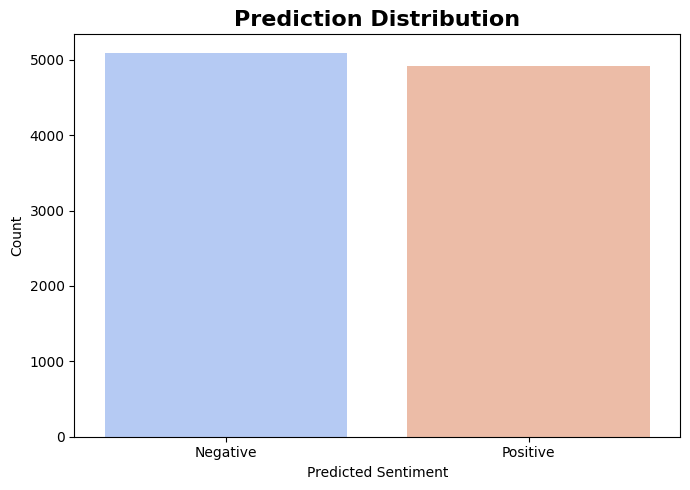

In [74]:
# Prediction Distribution Chart

prediction_counts = pd.Series(y_pred).value_counts()

# Rename Labels
prediction_counts.index = ['Negative', 'Positive']

plt.figure(figsize=(7,5))

sns.barplot(
    x=prediction_counts.index,
    y=prediction_counts.values,
    palette='coolwarm'
)

plt.title(
    'Prediction Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Count')

# Save Chart
plt.savefig(
    'Charts/prediction_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()

plt.show()

In [75]:
import os

print(os.listdir('Charts'))

['sentiment_distribution.png', 'sentiment_percentage_pie_chart.png', 'prediction_distribution.png', 'review_length_distribution.png', 'negative_wordcloud.png', 'top_positive_words.png', 'confusion_matrix.png', 'positive_wordcloud.png', 'top_negative_words.png', 'review_length_comparison.png']
